# Color Transfer EDA

In [1]:
import os
import sys
from jax import config

# things for jax
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["XLA_PYTHON_CLIENT_ALLOCATOR"] = "platform"
os.environ.setdefault("JAX_PLATFORM_NAME", "cpu")
config.update("jax_enable_x64", True)

# maybe need this to import module uot
# sys.path.insert(0, os.path.abspath(".."))

In [2]:
from pathlib import Path
import logging

from typing import Callable

import numpy as np
import pandas as pd

from matplotlib import pyplot as plt
import seaborn as sns

In [3]:
from pathlib import Path

from color_transfer_data_loader import load_color_transfer_data, extract_image_params

DATA_PATH = Path("../color_transfer_data2")
df, load_image = load_color_transfer_data(DATA_PATH)

print(f"Number of loaded problem instances {len(df)}")


Number of loaded problem instances 3600


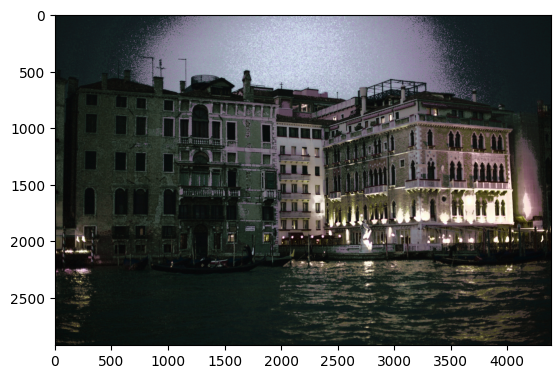

In [4]:
# df_valid = df[df['result_image_filename'].notna() & (df['result_image_filename'].astype(str).str.len() > 0)]
# if df_valid.empty:
#     raise ValueError('No rows with result_image_filename found. Check DATA_PATH and output images folder.')
# row = df_valid.iloc[0]
row = df.iloc[7]
params = extract_image_params(row)
img = load_image(row.get('dataset', row.get('name')), row['solver'], params)
# if img is None:
#     raise FileNotFoundError(f"Image not found for {row.get('result_image_filename')} in results folder.")
plt.imshow(img)


In [5]:
df.head()

,time,cost,bins_per_channel,sinkhorn_divergence,kl_divergence,tv_mu_to_nu,ma_residual_L1,ma_residual_Linf,map_diffuseness,ssim,...,run_folder,marginal_error_L2,pushforward_fn_name,maxiter,tol,error_metric,stepsize,stepsize_lower_bound,pushforward_fn,reg
0,11.285898,0.236638,52,0.042933,1.012969,1.639395e-15,9.988939,0.420925,0.014089,0.512228,...,simplex,NaN,NaN,2000000.0,1.000000e-12,NaN,NaN,NaN,NaN,0.0
1,11.285898,0.236638,52,0.151646,1.693251,1.639395e-15,1.622430,0.014244,0.014089,0.820180,...,simplex,NaN,NaN,2000000.0,1.000000e-12,NaN,NaN,NaN,NaN,0.0
2,11.285898,0.236638,52,0.102834,1.381620,1.639395e-15,2.446439,0.034231,0.014089,0.705994,...,simplex,NaN,NaN,2000000.0,1.000000e-12,NaN,NaN,NaN,NaN,0.0
3,11.285898,0.236638,52,0.057820,1.169305,1.639395e-15,4.305052,0.123731,0.014089,0.600868,...,simplex,NaN,NaN,2000000.0,1.000000e-12,NaN,NaN,NaN,NaN,0.0
4,69.340504,0.298481,52,0.094872,0.623730,7.930759e-15,97.918923,4.675302,0.001707,0.417619,...,simplex,NaN,NaN,2000000.0,1.000000e-12,NaN,NaN,NaN,NaN,0.0


| Statistical Columns | Parametric Columns | Definitive Columns |
|---|---|---|
| `time` | `bins_per_channel` | `name` |
| `cost` | `displacement_alpha` | `dataset` |
| `sinkhorn_divergence` | `mu_size, nu_size` | `status` |
| `kl_divergence` | `reg` | |
| `tv_mu_to_nu` |  |  |
| `ma_residual_L1` |  |
| `ma_residual_Linf` |  |
| `map_diffuseness` |  |
| `ssim` |  |
| `colorfulness_diff` |  |
| `gradient_correlation` |  |
| `laplacian_sharpness_diff` |  |
| `iterations` |  |
| `error` |  |

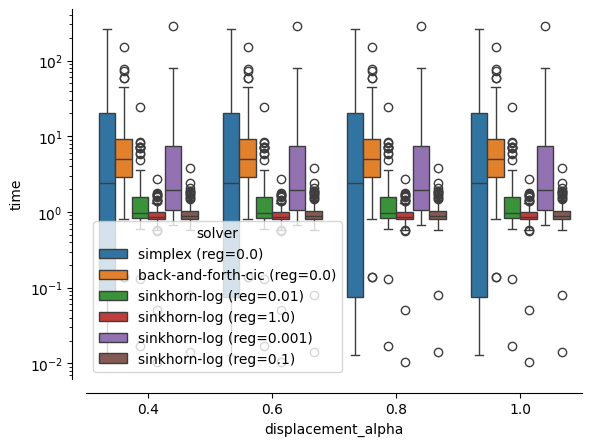

In [6]:
fig, axs = plt.subplots()
sns.boxplot(
    x='displacement_alpha',
    y='time',
    hue='solver',
    data=df,
    log_scale=True,
)
sns.despine(offset=10)

In [7]:
metrics = [
    "sinkhorn_divergence",
    "time",
    "kl_divergence",
    "ma_residual_L1",
    "ssim",
    "colorfulness_diff",
    "gradient_correlation",
    "laplacian_sharpness_diff",
]
log_scale_metrics = {
    "time",
    "error",
    "iterations",   # maybe...

    "sinkhorn_divergence",
    "kl_divergence",

    "ma_residual_L1",
    "ma_residual_Linf",
    "tv_mu_to_nu",

    # "laplacian_sharpness_diff",
}

In [8]:
def build_facet_boxplots(data, title):
    g = sns.FacetGrid(
        data=data,
        row="metric",
        col="bins_per_channel",
        sharey=False,        # IMPORTANT: different scales
        sharex=False,
        height=3.0,
        aspect=1.6,
    )
    g.figure.subplots_adjust(
        wspace=0.30,
        hspace=0.40,
    )
    g.figure.suptitle(title)

    def conditional_boxplot(data, **kwargs):
        ax = plt.gca()
        sns.boxplot(data=data, **kwargs)
        if data['metric'].iloc[0] in log_scale_metrics:
            ax.set_yscale('log')

    g.map_dataframe(
        # sns.boxplot,
        conditional_boxplot,
        x="displacement_alpha",
        y="value",
        hue="solver",
        palette="deep",
    )

    g.add_legend(title="Method")
    sns.despine(offset=10)
    return g

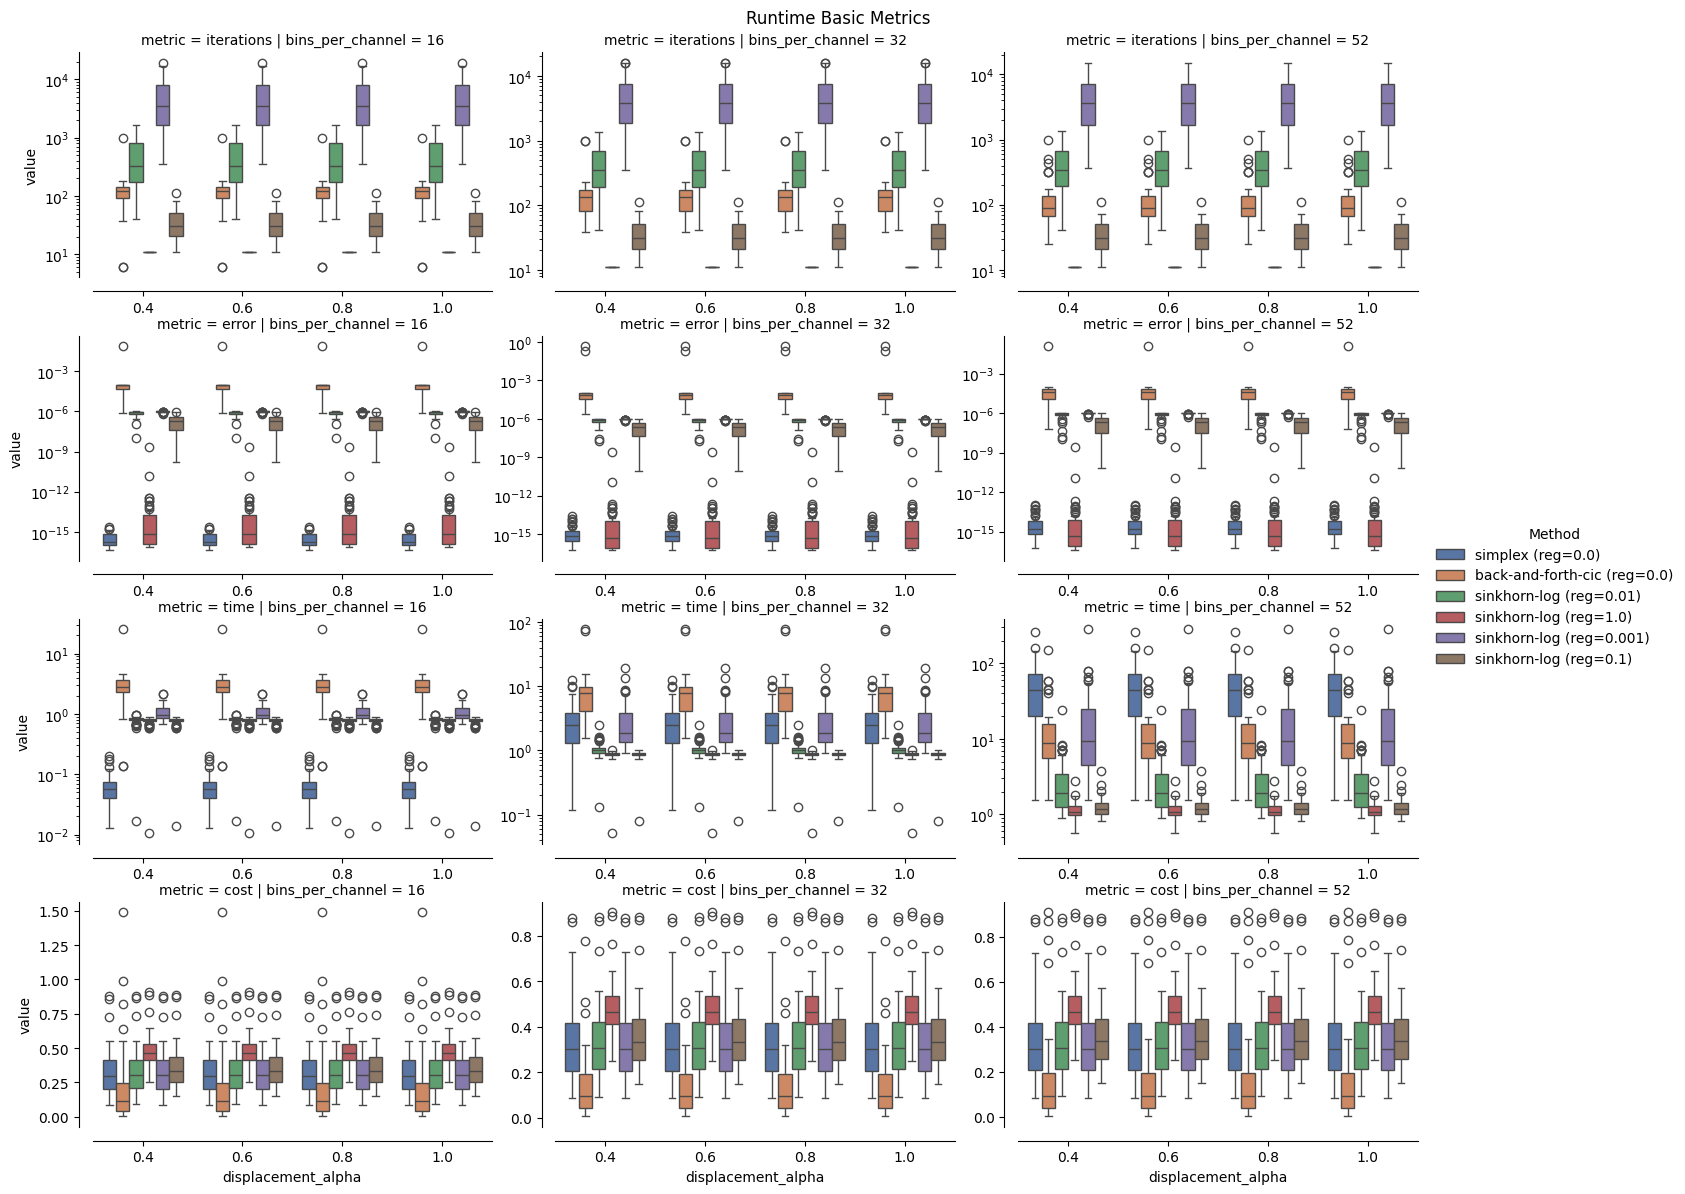

In [9]:
runtime_metrics = [
    "iterations",
    "error",
    "time",
    "cost",
]
df_runtime_basic_metrics = df.melt(
    id_vars=["bins_per_channel", "displacement_alpha", "solver"],
    value_vars=runtime_metrics,
    var_name="metric",
    value_name="value",
)
build_facet_boxplots(df_runtime_basic_metrics, "Runtime Basic Metrics")

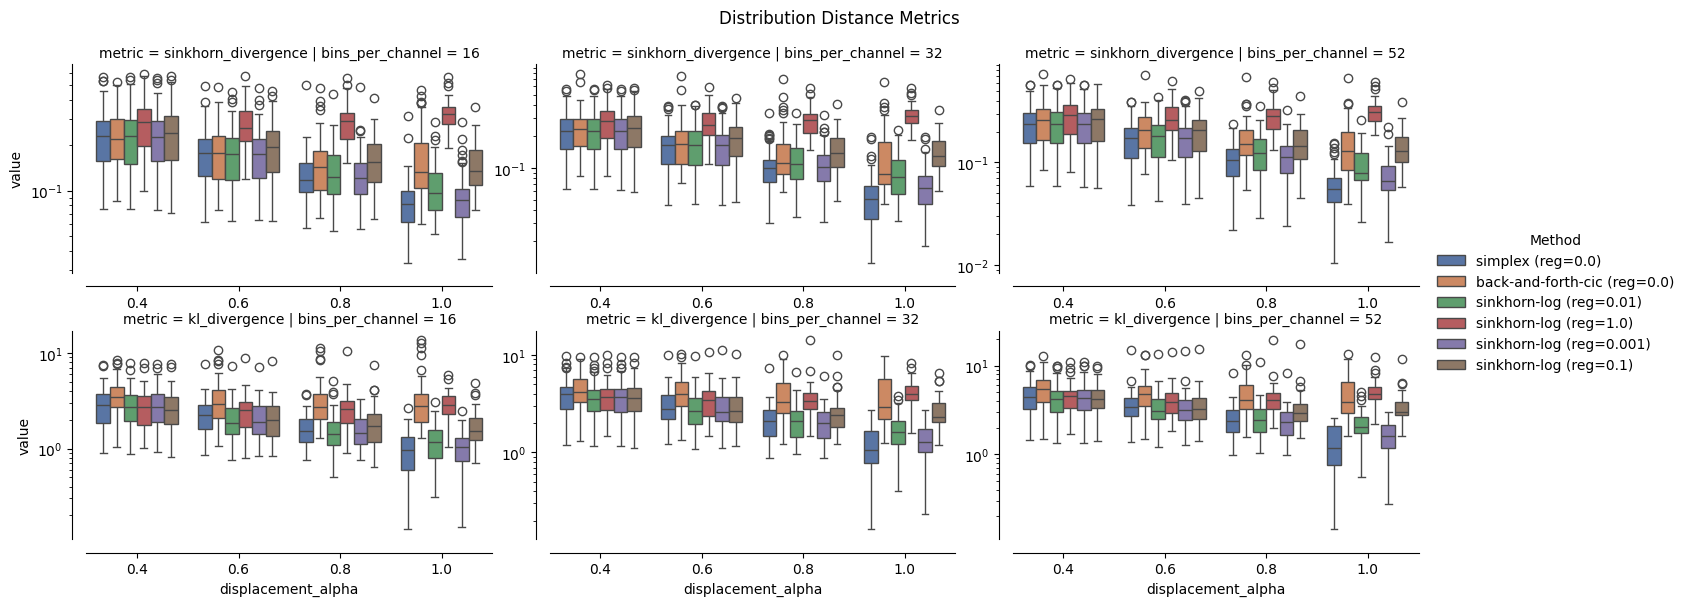

In [10]:
distance_metrics = [
    "sinkhorn_divergence",
    "kl_divergence",
]
df_distance_metrics = df.melt(
    id_vars=["bins_per_channel", "displacement_alpha", "solver"],
    value_vars=distance_metrics,
    var_name="metric",
    value_name="value",
)
build_facet_boxplots(df_distance_metrics, "Distribution Distance Metrics")

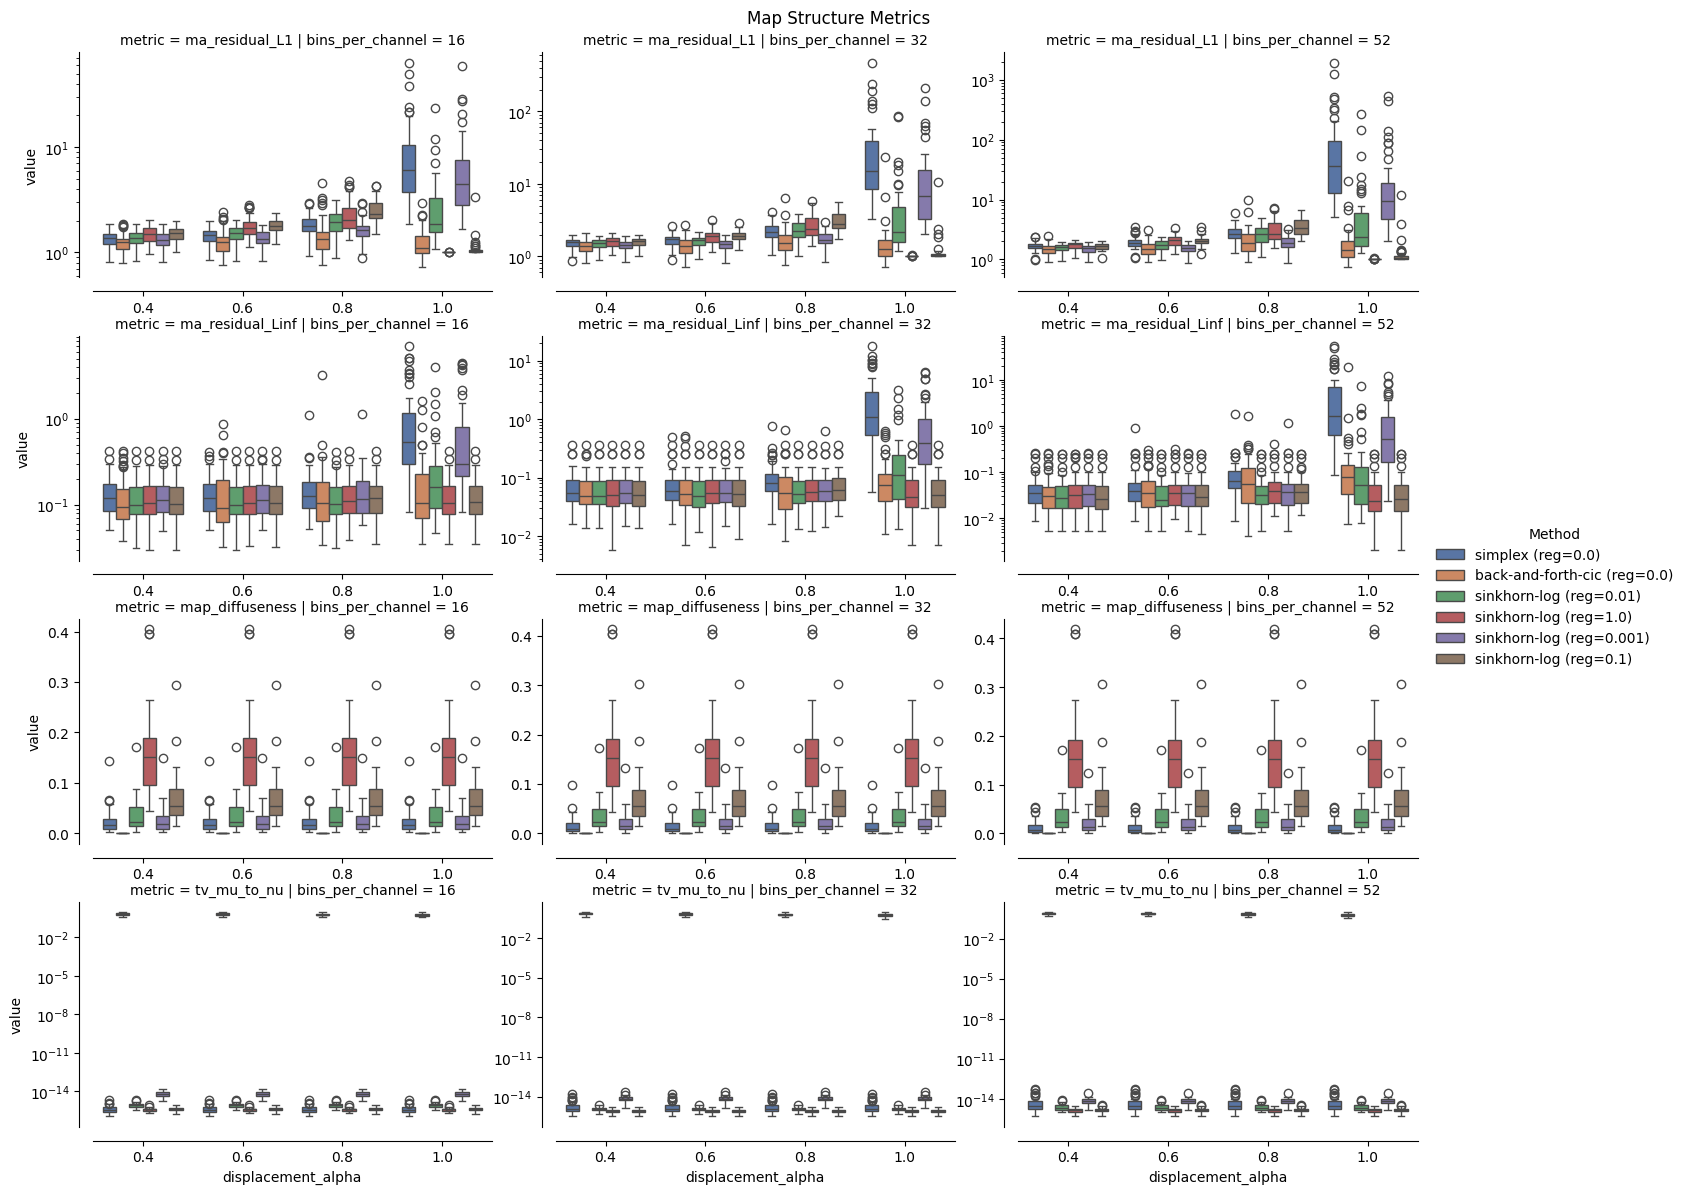

In [11]:
map_structure_metrics = [
    "ma_residual_L1",
    "ma_residual_Linf",
    "map_diffuseness",
    "tv_mu_to_nu",
]
df_map_structure_metrics = df.melt(
    id_vars=["bins_per_channel", "displacement_alpha", "solver"],
    value_vars=map_structure_metrics,
    var_name="metric",
    value_name="value",
)
build_facet_boxplots(df_map_structure_metrics, "Map Structure Metrics")

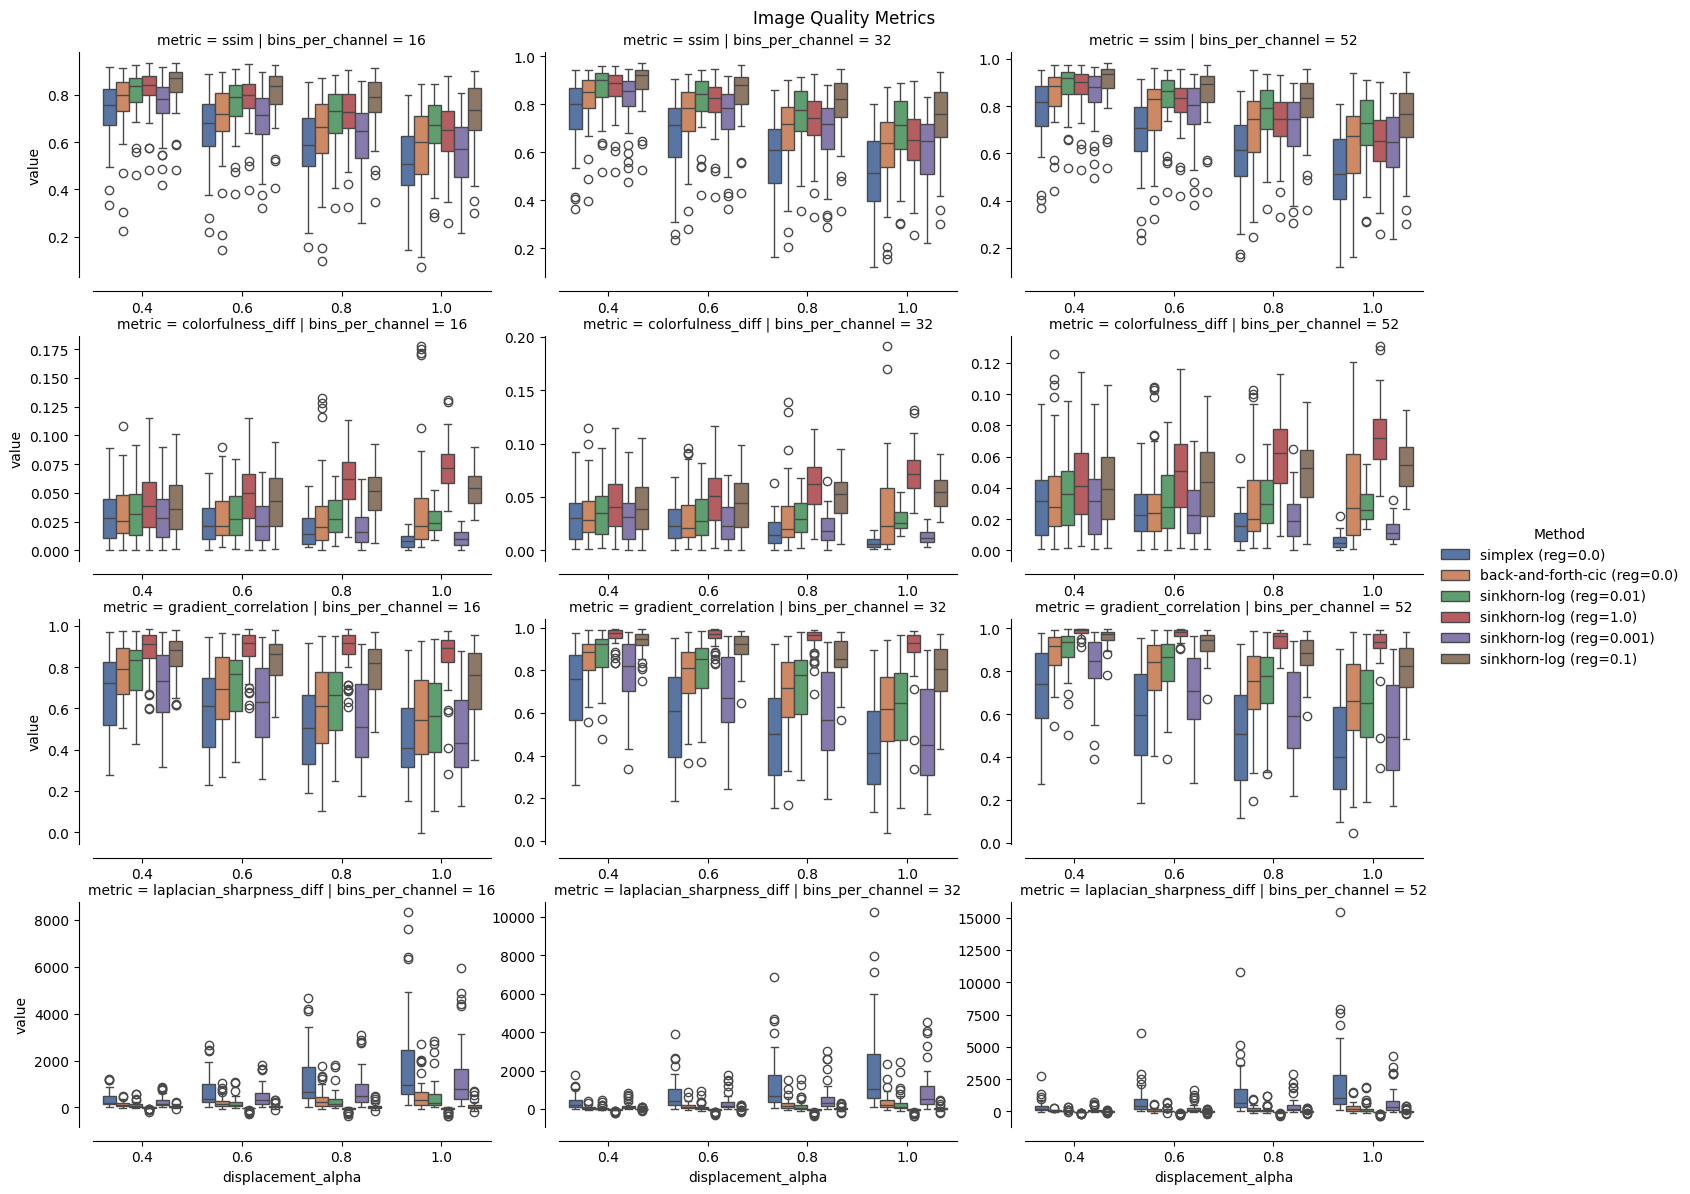

In [12]:
image_quality_metrics = [
    "ssim",
    "colorfulness_diff",
    "gradient_correlation",
    "laplacian_sharpness_diff",
]
df_image_quality_metrics = df.melt(
    id_vars=["bins_per_channel", "displacement_alpha", "solver"],
    value_vars=image_quality_metrics,
    var_name="metric",
    value_name="value",
)
build_facet_boxplots(df_image_quality_metrics, "Image Quality Metrics")